## Yi CNN Model ver3

*Patch Notes: ver3 Updates*  
This version added the following implementations:
* Added a proper validation set: carve a seeded 15% split out of `Training/` (seed=42) so train/val/test are fully separate. `Testing/` is no longer used as a de-facto validation set during training (as in ver2) and is only touched once, at the very end, for an unbiased final evaluation.
* Checkpoint the best-validation-loss weights during training and restore them before the final test evaluation, instead of keeping whatever the last epoch happened to produce.
* Weighted glioma 2x higher in the loss function to address its comparatively weak recall (see confusion matrix) — recall improved from 71% to 76% on the held-out test set, with overall test accuracy moving from 89.4% to 90.2%.
* Split the final test evaluation into its own step, run exactly once after training/model selection is complete.

## Data Loading and Visualization

This section loads the images, splits into train, validation, test sets, completes proper transform or augmentation, and then does a brief visualization.

Mounted at /content/drive
Data loaded: train=4760, val=840, test=1600


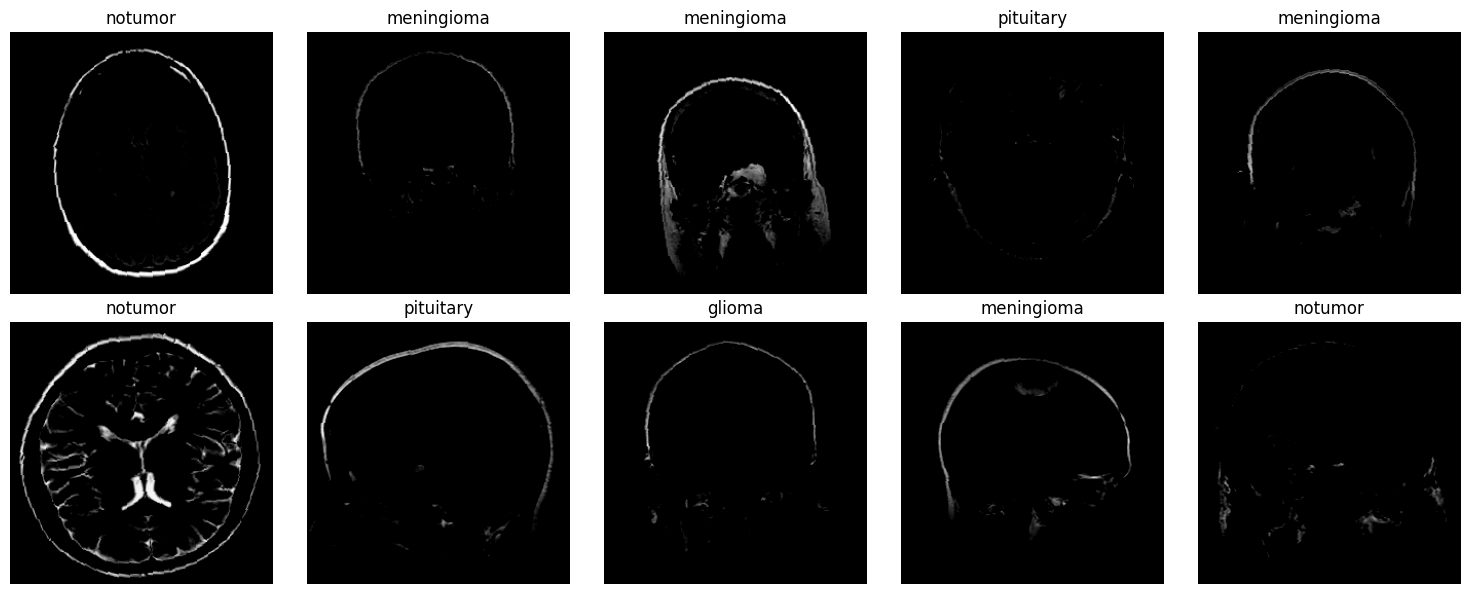

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')


# transform to make all images 256*256 and preprocessing
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),

    # add data augmentation for training
    transforms.RandomRotation(8),

    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08
    ),


    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])


# I put it in content/dataset rather than google drive to fasten the training process
!cp -r "/content/drive/MyDrive/brain_mri_dataset/" "/content/dataset"
train_path = '/content/dataset/Training/'
test_path = '/content/dataset/Testing/'

# load the Training folder twice (once per transform) so the validation split gets clean, unaugmented images
train_dataset_aug = datasets.ImageFolder(root=train_path, transform=transform_train)
train_dataset_val = datasets.ImageFolder(root=train_path, transform=transform_test)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform_test)

# carve a validation split out of Training; Testing stays untouched until final evaluation
val_ratio = 0.15
val_size = int(len(train_dataset_aug) * val_ratio)
train_size = len(train_dataset_aug) - val_size

split_generator = torch.Generator().manual_seed(42)
train_split, val_split = torch.utils.data.random_split(range(len(train_dataset_aug)), [train_size, val_size], generator=split_generator)

train_dataset = torch.utils.data.Subset(train_dataset_aug, train_split.indices)
val_dataset = torch.utils.data.Subset(train_dataset_val, val_split.indices)

# image data loading in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Data loaded: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

# pulls batch of 10 images to display
images, labels = next(iter(train_loader))

# class names corresponding to the folder names
class_names = train_dataset_aug.classes

# plot the first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()

for i in range(10):
    # PyTorch images (Channels, Height, Width) --> Matplotlib images (Height, Width, Channels)
    img = images[i].permute(1, 2, 0).numpy()

    axes[i].imshow(img) # should fix in the future to denormalize during imshow to silence warnings
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Model Definition and Training

Define the CNN architecture, then set up the training/evaluation loop: a training function, an evaluation function, and the epoch loop that ties them together.

In [2]:
import torch.nn as nn
import torch.optim as optim
import copy


from sklearn.metrics import f1_score, classification_report

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 256 -> 128
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 128 -> 64
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(4, 4) # 64 -> 16
        )

        self.avgpool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes),

        )


    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [4]:
# hyperparameters
num_epochs = 30
learning_rate = 1e-3

model = SimpleCNN(num_classes=len(class_names))
model = model.cuda() # I'm running on Google Colab GPU; pls change to your device when running on local machine

# glioma has the weakest recall (see confusion matrix), so weight its loss higher;
# a missed glioma costs more than the model being cautious about the other classes
class_weights = torch.tensor(
    [2.0 if name == 'glioma' else 1.0 for name in class_names]
).cuda()
criterion = nn.CrossEntropyLoss(label_smoothing=0.05, weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Runs one training epoch, and returns (avg_loss, accuracy)."""
    model.train()

    running_loss = 0.0
    num_correct = 0
    num_samples = 0

    for t, (x, y) in enumerate(loader):
        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        predicted = torch.max(output, 1)[1]
        num_correct += (predicted == y).sum().item()
        num_samples += y.size(0)
        if t % 10 == 0:
            batch_acc = (predicted == y).sum().item() / y.size(0)
            print('Iteration %d, Train: batch_loss=%.2f, acc=%.4f' % (t, loss.item(), batch_acc))

    avg_loss = running_loss / num_samples
    accuracy = num_correct / num_samples
    return avg_loss, accuracy

In [6]:
def test(model, loader, criterion):
    """Runs evaluation, and returns (avg_loss, accuracy)."""
    model.eval()

    running_loss = 0.0
    num_correct = 0
    num_samples = 0
    all_preds, all_labels = [], []


    with torch.no_grad():
        for x, y in loader:
            x = x.cuda()
            y = y.cuda()

            output = model(x)
            loss = criterion(output, y)

            running_loss += loss.item() * x.size(0)
            predicted = torch.max(output, 1)[1]
            num_correct += (predicted == y).sum().item()
            num_samples += y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())


    avg_loss = running_loss / num_samples
    accuracy = num_correct / num_samples
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, accuracy, f1, all_preds, all_labels

In [7]:
# Track metrics across epochs for plotting
train_losses, train_accs = [], []
val_losses, val_accs, val_f1s = [], [], []
lrs = []

best_val_loss = float('inf')
best_model_state = None

for e in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

    val_loss, val_acc, val_f1, val_preds, val_labels = test(model, val_loader, criterion)

    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print('Epoch %d, Train: avg_loss=%.2f, acc=%.4f' % (e, train_loss, train_acc))
    print('Epoch %d, Val: avg_loss=%.2f, acc=%.4f, f1=%.4f' % (e, val_loss, val_acc, val_f1))

    # checkpoint the best-so-far weights by validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

# restore the best-performing weights (by validation loss) before final testing
model.load_state_dict(best_model_state)
print('Training finished! Best validation loss: %.4f' % best_val_loss)

Iteration 0, Train: batch_loss=1.52, acc=0.1875
Iteration 10, Train: batch_loss=1.39, acc=0.4062
Iteration 20, Train: batch_loss=0.97, acc=0.6719
Iteration 30, Train: batch_loss=0.87, acc=0.6719
Iteration 40, Train: batch_loss=0.84, acc=0.7500
Iteration 50, Train: batch_loss=0.77, acc=0.7344
Iteration 60, Train: batch_loss=0.93, acc=0.6562
Iteration 70, Train: batch_loss=0.73, acc=0.7344
Epoch 0, Train: avg_loss=0.99, acc=0.6189
Epoch 0, Val: avg_loss=0.72, acc=0.7405, f1=0.7335
Iteration 0, Train: batch_loss=0.74, acc=0.7656
Iteration 10, Train: batch_loss=0.75, acc=0.7031
Iteration 20, Train: batch_loss=0.68, acc=0.7656
Iteration 30, Train: batch_loss=0.58, acc=0.7188
Iteration 40, Train: batch_loss=0.57, acc=0.8594
Iteration 50, Train: batch_loss=0.70, acc=0.7969
Iteration 60, Train: batch_loss=0.61, acc=0.8281
Iteration 70, Train: batch_loss=0.66, acc=0.7656
Epoch 1, Train: avg_loss=0.70, acc=0.7479
Epoch 1, Val: avg_loss=0.63, acc=0.8000, f1=0.7956
Iteration 0, Train: batch_loss=0

## Final Held-Out Test Evaluation

The Testing set was never touched during training or model selection above. Now that the best validation checkpoint is loaded, run it through the Testing set exactly once to get an unbiased performance estimate.

In [8]:
test_loss, test_acc, test_f1, test_preds, test_labels = test(model, test_loader, criterion)

print('Final Held-Out Test: avg_loss=%.4f, acc=%.4f, f1=%.4f' % (test_loss, test_acc, test_f1))
print(classification_report(test_labels, test_preds, target_names=class_names))

Final Held-Out Test: avg_loss=0.5142, acc=0.9019, f1=0.8997
              precision    recall  f1-score   support

      glioma       0.95      0.76      0.84       400
  meningioma       0.90      0.86      0.88       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



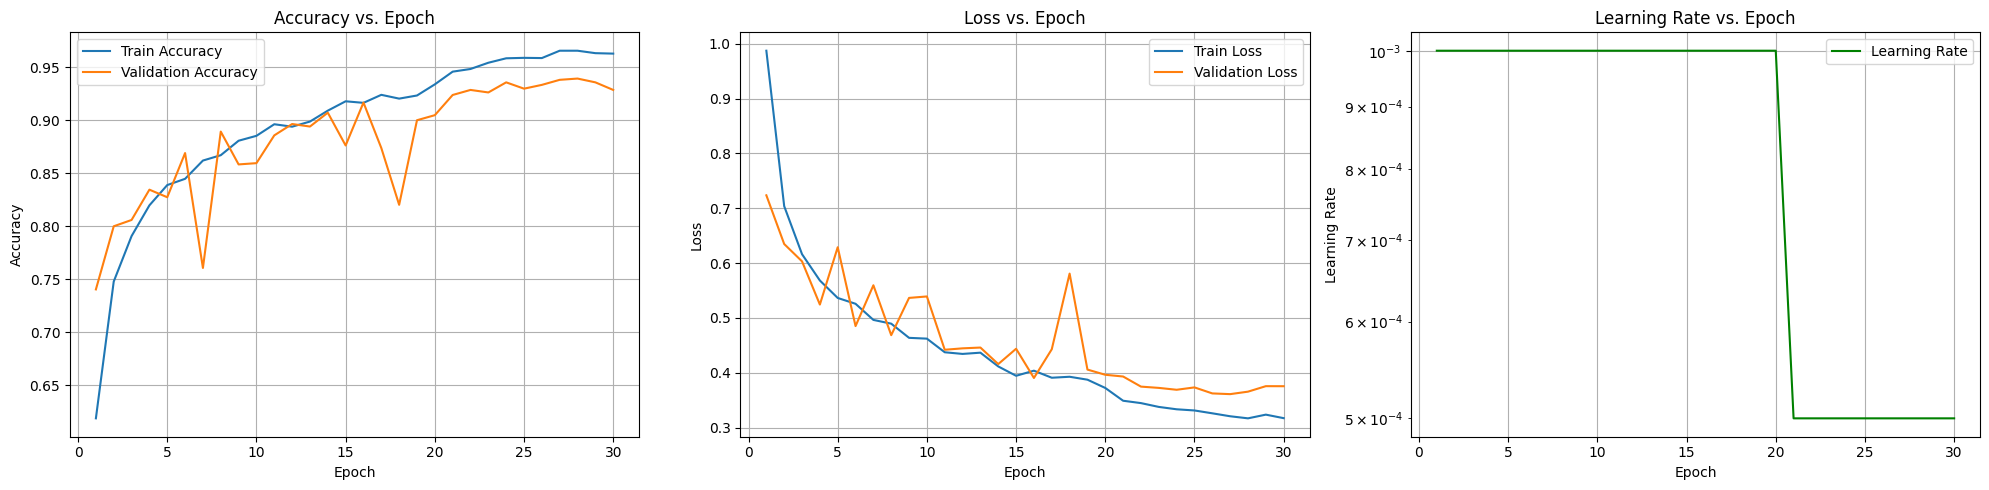

In [9]:
# plot curves here if needed
epochs_range = range(1, len(train_accs) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_range, train_accs, label='Train Accuracy')
axes[0].plot(epochs_range, val_accs, label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs. Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, train_losses, label='Train Loss')
axes[1].plot(epochs_range, val_losses, label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs. Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs_range, lrs, label='Learning Rate', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')
axes[2].set_title('Learning Rate vs. Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

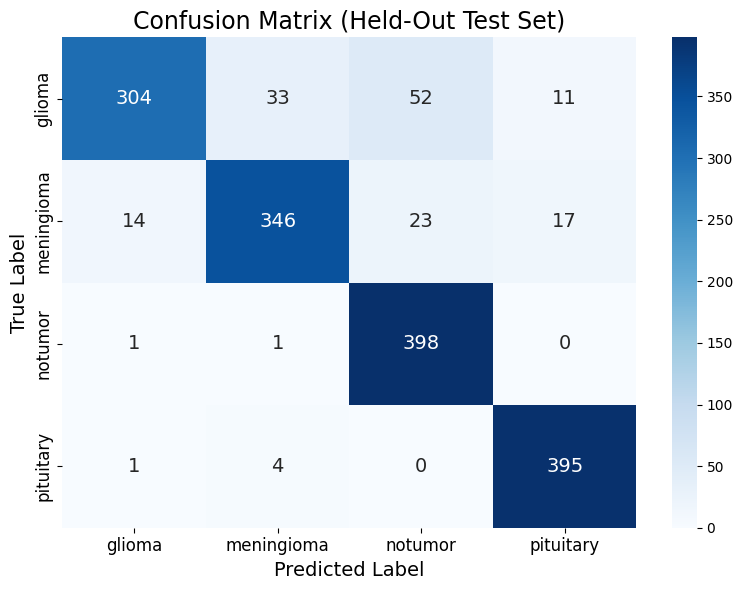

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 14}
)

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix (Held-Out Test Set)', fontsize=17)

plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
torch.save(model.state_dict(), 'yi_cnn_ver3_result.pth')
# model.load_state_dict(torch.load('yi_cnn_ver3_result.pth'))